In [ ]:
import os
from matplotlib import pyplot as plt
import numpy as np
from skimage import img_as_float, io, morphology,color
from skimage.segmentation import random_walker
from skimage.measure import label
from PIL import Image

low_threshold: float = 0.2
high_threshold: float = 0.9
beta: int = 10
min_size: int = 100
dpi: int = 400

element_label= "Cd"

In [17]:
from geomap import GeoMap

gmap = GeoMap("地图\湘潭县界.shp")

In [18]:
import pandas as pd
from dataprocess import kringing

data = pd.read_excel("数据\水稻点位148.xlsx")

gmap.load_dots_df(data)
kringing_path = kringing(data, num=100)
gmap.load_dots_df(pd.read_excel(kringing_path))
grid = gmap.grid_paint(20, 20)

c:\Codes\Mission\agricultural-decision-system\.venv\lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Codes\Mission\agricultural-decision-system\.venv\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: '有效态Cd' to '有效态C'
  ogr_write(


插值数据保存成功！


In [19]:
value_matrix = grid.set_value_matrix(element_label)

In [20]:
value_matrix

array([[        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan, 25.86433305,         nan,         nan,
                nan,         nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan, 25.67685328, 26.06504574, 26.73742111, 27.55012261,
        25.85088911,         nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan, 22.38695239, 24.11812172,
        26.57990852, 27.32910257, 26.78822125, 26.6396489 , 26.86845665,
        25.77205783,         nan,         nan,         nan,         nan],
       [        nan,         nan,         nan, 19.56560893, 19.68931074,
                nan,         nan,         nan, 2

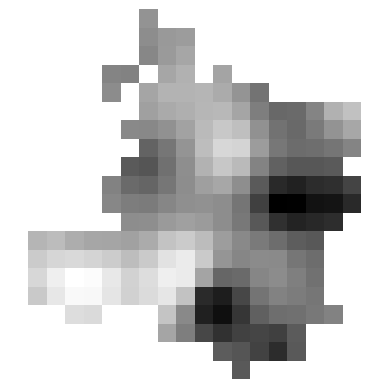

In [21]:
fig, ax = plt.subplots()
im = ax.imshow(value_matrix, origin="lower", cmap="Greys")
ax.axis("off")

file_path = os.path.join(".", "Images", f"img_grid_{element_label}_grey.png")
fig.savefig(file_path)

In [22]:
img = np.sqrt(1 - io.imread(f"Images\img_grid_{element_label}_grey.png", as_gray=True))

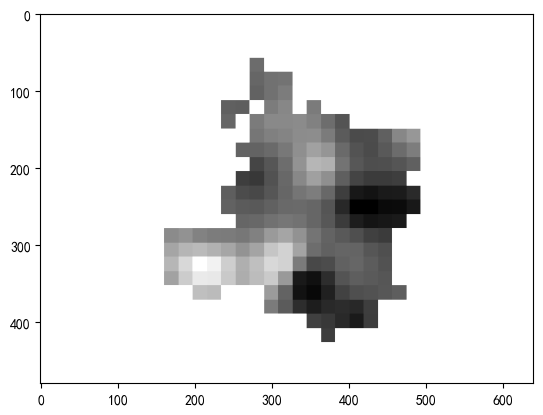

In [23]:
plt.imshow(img,cmap="Greys")

In [24]:
# 随机游走分割
markers: np.ndarray = np.zeros_like(img)
markers[img > high_threshold] = 1
markers[img < low_threshold] = 2
seg_result = random_walker(img, markers, beta=beta, mode="bf")

In [25]:
# 区域处理，去除最小区域
label_img = label(seg_result)
filtered_regions = morphology.remove_small_objects(label_img, min_size)
(filtered_regions).mean()

np.float64(1.0814778645833334)

In [26]:
# 二值化处理
prop_bw = filtered_regions
prop_bw[prop_bw == 1] = 0
prop_bw[prop_bw >= 1] = 1

In [27]:
(prop_bw).mean()

np.float64(0.08147786458333334)

In [28]:
# 骨架化
skeleton = morphology.skeletonize(prop_bw)

(skeleton).mean()

np.float64(0.0006998697916666667)

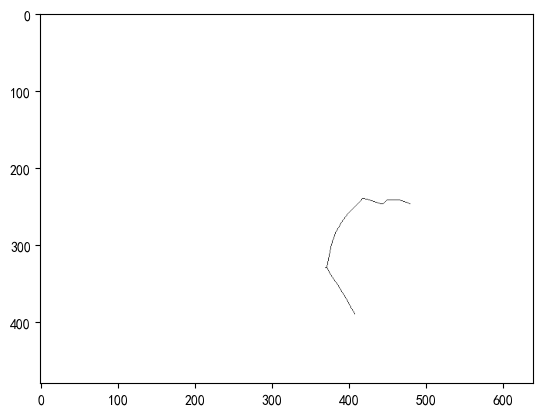

In [29]:
plt.imshow(skeleton,cmap="Greys")

C:\Users\27605\AppData\Local\Temp\ipykernel_10604\3664283866.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


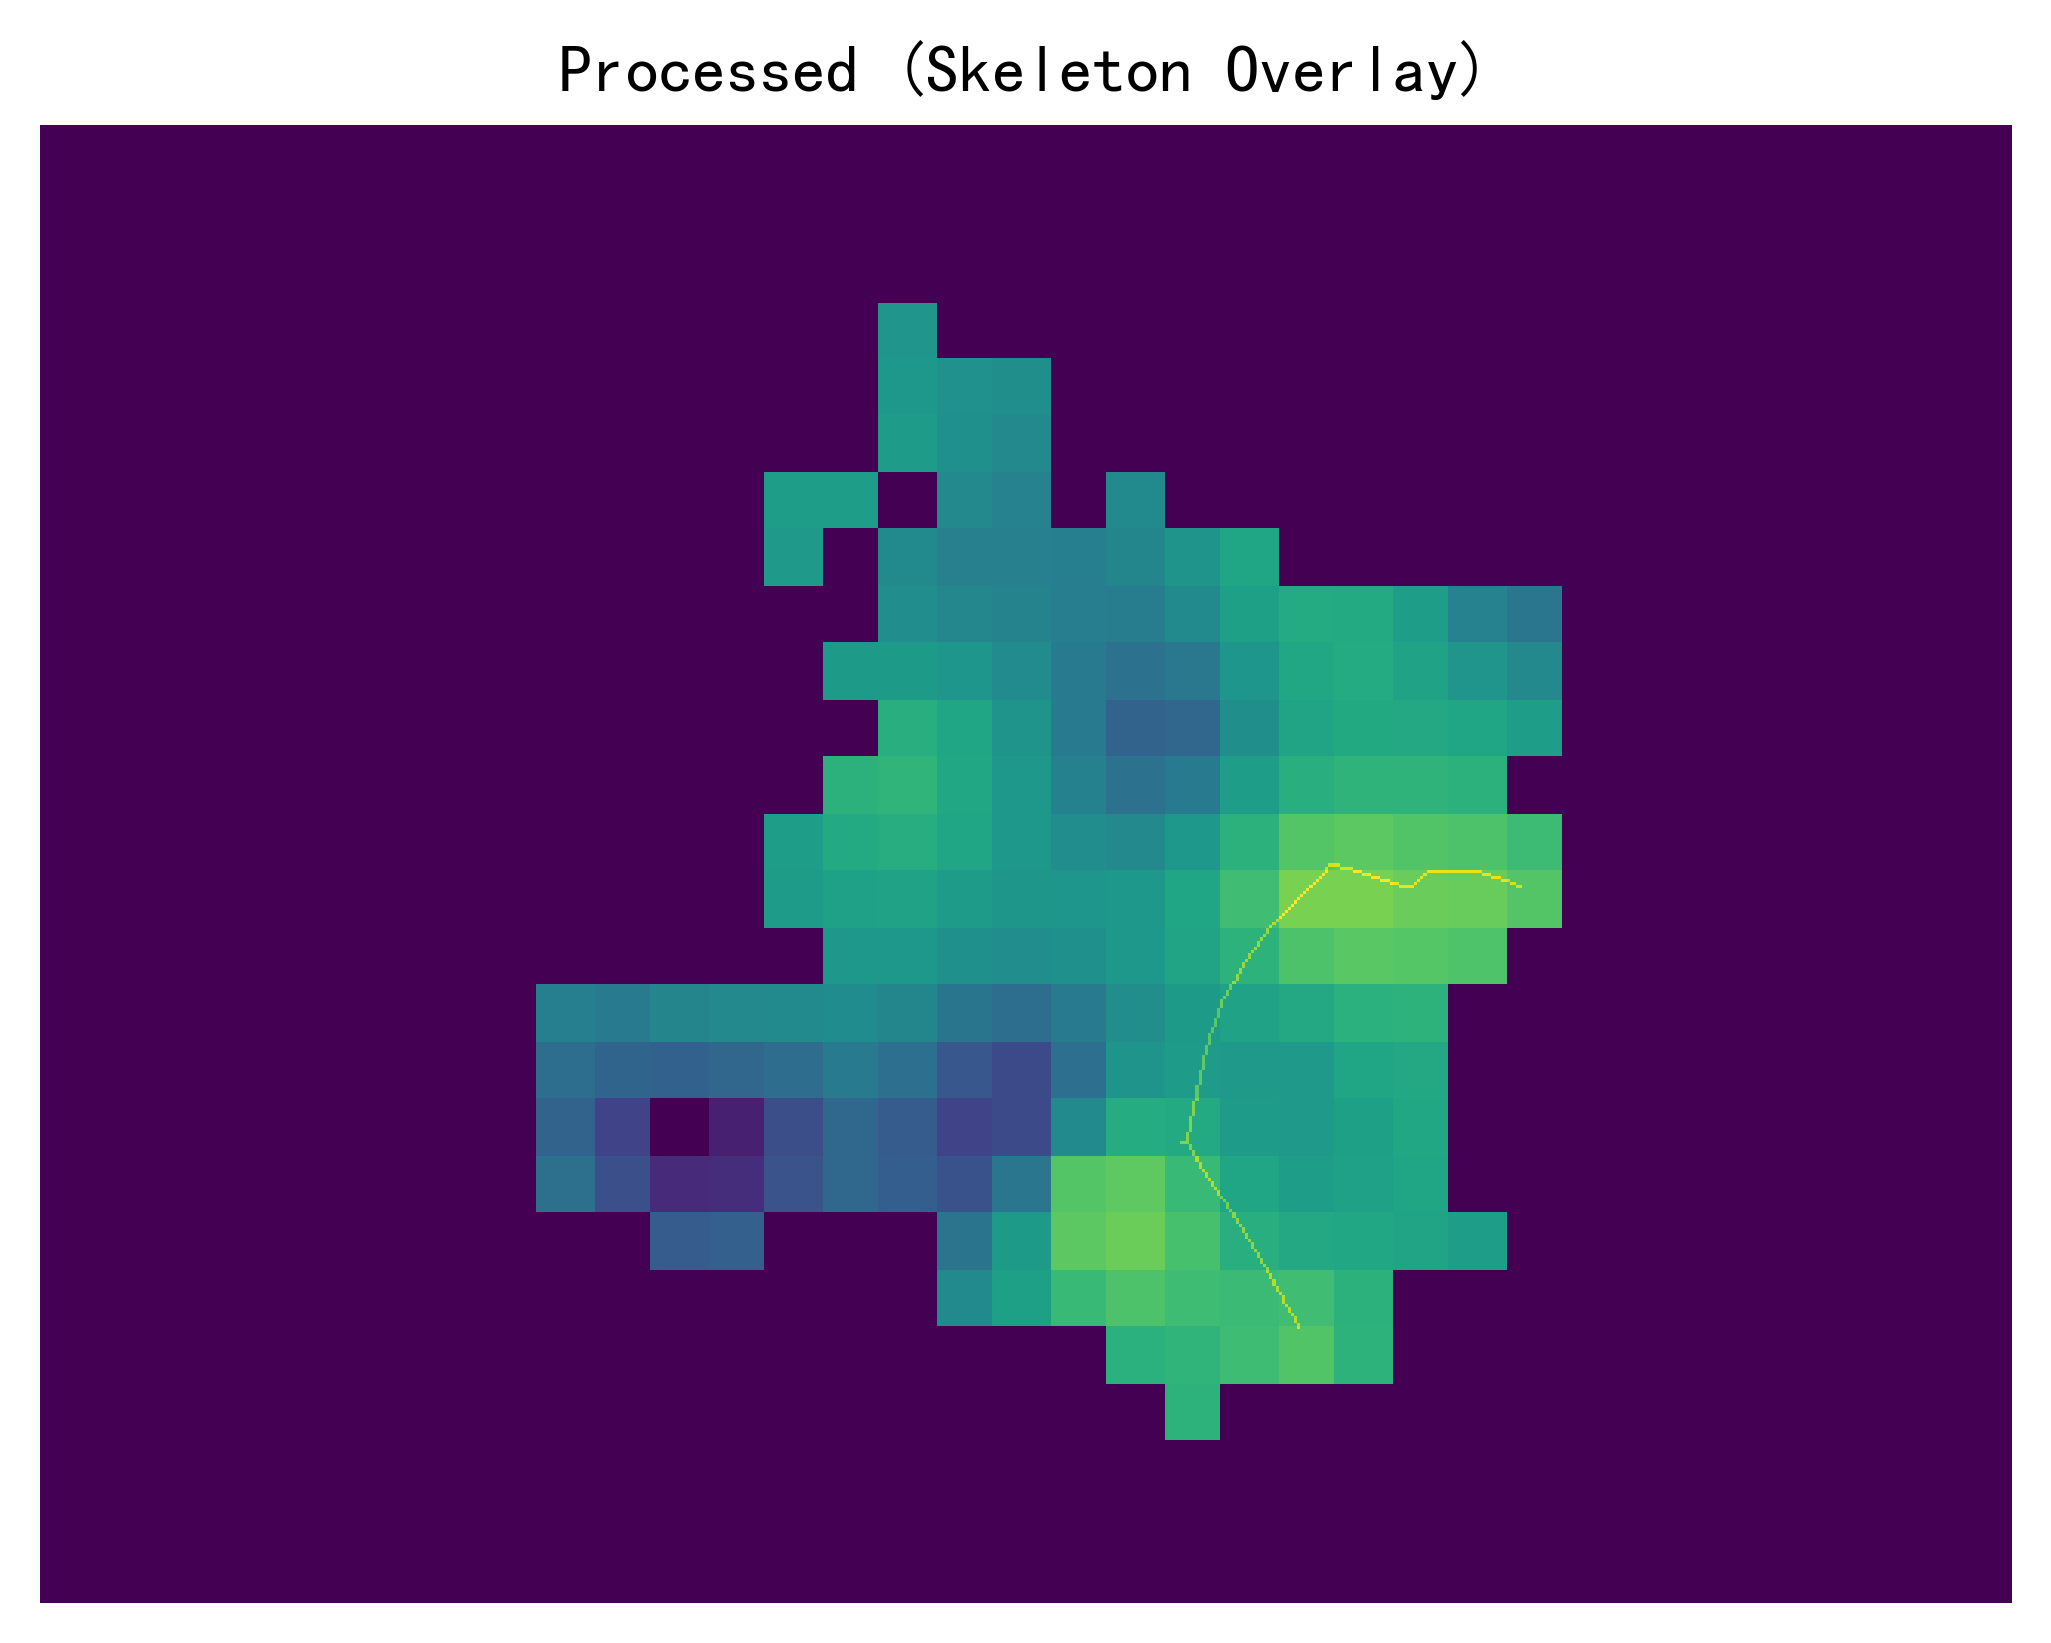

In [30]:
# 显示并保存结果
fig, ax = plt.subplots(dpi=400)

k = 0.8
ax.imshow(img * k + np.double(skeleton) * (1 - k))
ax.axis("off")
ax.set_title("Processed (Skeleton Overlay)", fontsize=12)

fig.show()